In [3]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visuals
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Using scikit-learn to load the breast cancer dataset
from sklearn.datasets import load_breast_cancer

# Load the data
cancer = load_breast_cancer()

# Converting to DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

# Map target to meaningful labels
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print("Dataset loaded successfully!")
print(f"Shape of dataset: {df.shape}")

Dataset loaded successfully!
Shape of dataset: (569, 32)


In [6]:
# 1. Basic Information
print("=== Dataset Shape ===")
print(df.shape)

print("\n=== First 5 Rows ===")
print(df.head())

print("\n=== Column Names ===")
print(df.columns.tolist())

=== Dataset Shape ===
(569, 32)

=== First 5 Rows ===
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst 

In [7]:
# 2. Data Types and Missing Values
print("\n=== Dataset Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum().sum())  # Total missing values


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoo

In [9]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [10]:
# 3. Target Distribution 
print("\n=== Diagnosis Distribution ===")
print(df['diagnosis'].value_counts())

print("\n=== Percentage ===")
print(df['diagnosis'].value_counts(normalize=True) * 100)


=== Diagnosis Distribution ===
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

=== Percentage ===
diagnosis
Benign       62.741652
Malignant    37.258348
Name: proportion, dtype: float64


In [11]:
# 4. Statistical Summary
print("=== Statistical Summary ===")
print(df.describe().round(2))

=== Statistical Summary ===
       mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
count       569.00        569.00          569.00     569.00           569.00   
mean         14.13         19.29           91.97     654.89             0.10   
std           3.52          4.30           24.30     351.91             0.01   
min           6.98          9.71           43.79     143.50             0.05   
25%          11.70         16.17           75.17     420.30             0.09   
50%          13.37         18.84           86.24     551.10             0.10   
75%          15.78         21.80          104.10     782.70             0.11   
max          28.11         39.28          188.50    2501.00             0.16   

       mean compactness  mean concavity  mean concave points  mean symmetry  \
count            569.00          569.00               569.00         569.00   
mean               0.10            0.09                 0.05           0.18   
std           

In [12]:
# 5. Comparing features between Malignant and Benign
print("\n=== Mean Values by Diagnosis ===")
comparison = df.groupby('diagnosis').mean().round(3)
print(comparison)


=== Mean Values by Diagnosis ===
           mean radius  mean texture  mean perimeter  mean area  \
diagnosis                                                         
Benign          12.147        17.915          78.075    462.790   
Malignant       17.463        21.605         115.365    978.376   

           mean smoothness  mean compactness  mean concavity  \
diagnosis                                                      
Benign               0.092             0.080           0.046   
Malignant            0.103             0.145           0.161   

           mean concave points  mean symmetry  mean fractal dimension  ...  \
diagnosis                                                              ...   
Benign                   0.026          0.174                   0.063  ...   
Malignant                0.088          0.193                   0.063  ...   

           worst texture  worst perimeter  worst area  worst smoothness  \
diagnosis                                           

C:\Users\johnpaul\AppData\Local\Temp\ipykernel_13924\791976416.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette=['#ff6666', '#66b3ff'])


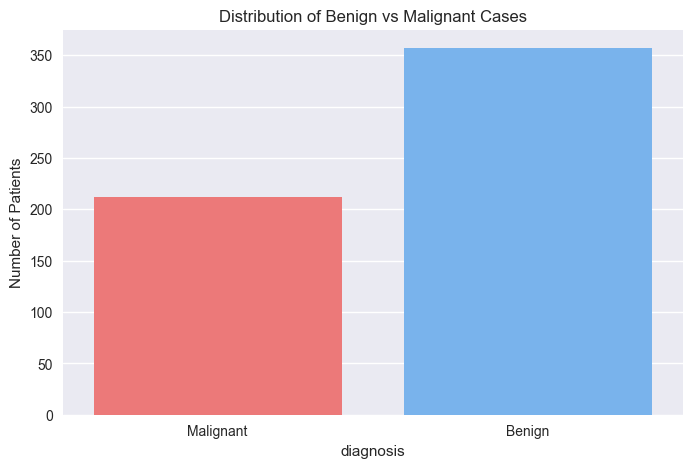

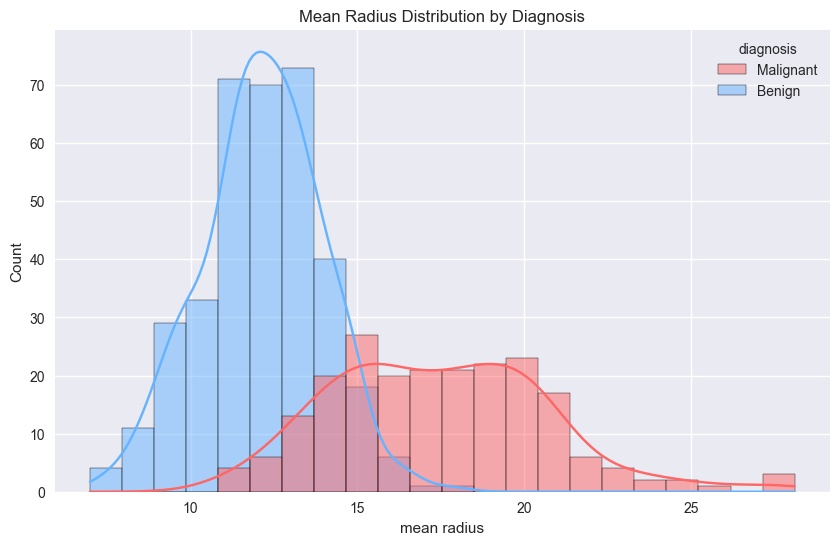

In [13]:
# 6. Visualizations

# Plot class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='diagnosis', data=df, palette=['#ff6666', '#66b3ff'])
plt.title('Distribution of Benign vs Malignant Cases')
plt.ylabel('Number of Patients')
plt.show()

# Plot distribution of one important feature (example: mean radius)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='mean radius', hue='diagnosis', kde=True, palette=['#ff6666', '#66b3ff'])
plt.title('Mean Radius Distribution by Diagnosis')
plt.show()

C:\Users\johnpaul\AppData\Local\Temp\ipykernel_13924\1723638868.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=feature, data=df, palette=['#ff6666', '#66b3ff'])
C:\Users\johnpaul\AppData\Local\Temp\ipykernel_13924\1723638868.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=feature, data=df, palette=['#ff6666', '#66b3ff'])
C:\Users\johnpaul\AppData\Local\Temp\ipykernel_13924\1723638868.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=feature, data=df, palette=['#ff6666', '#66b3f

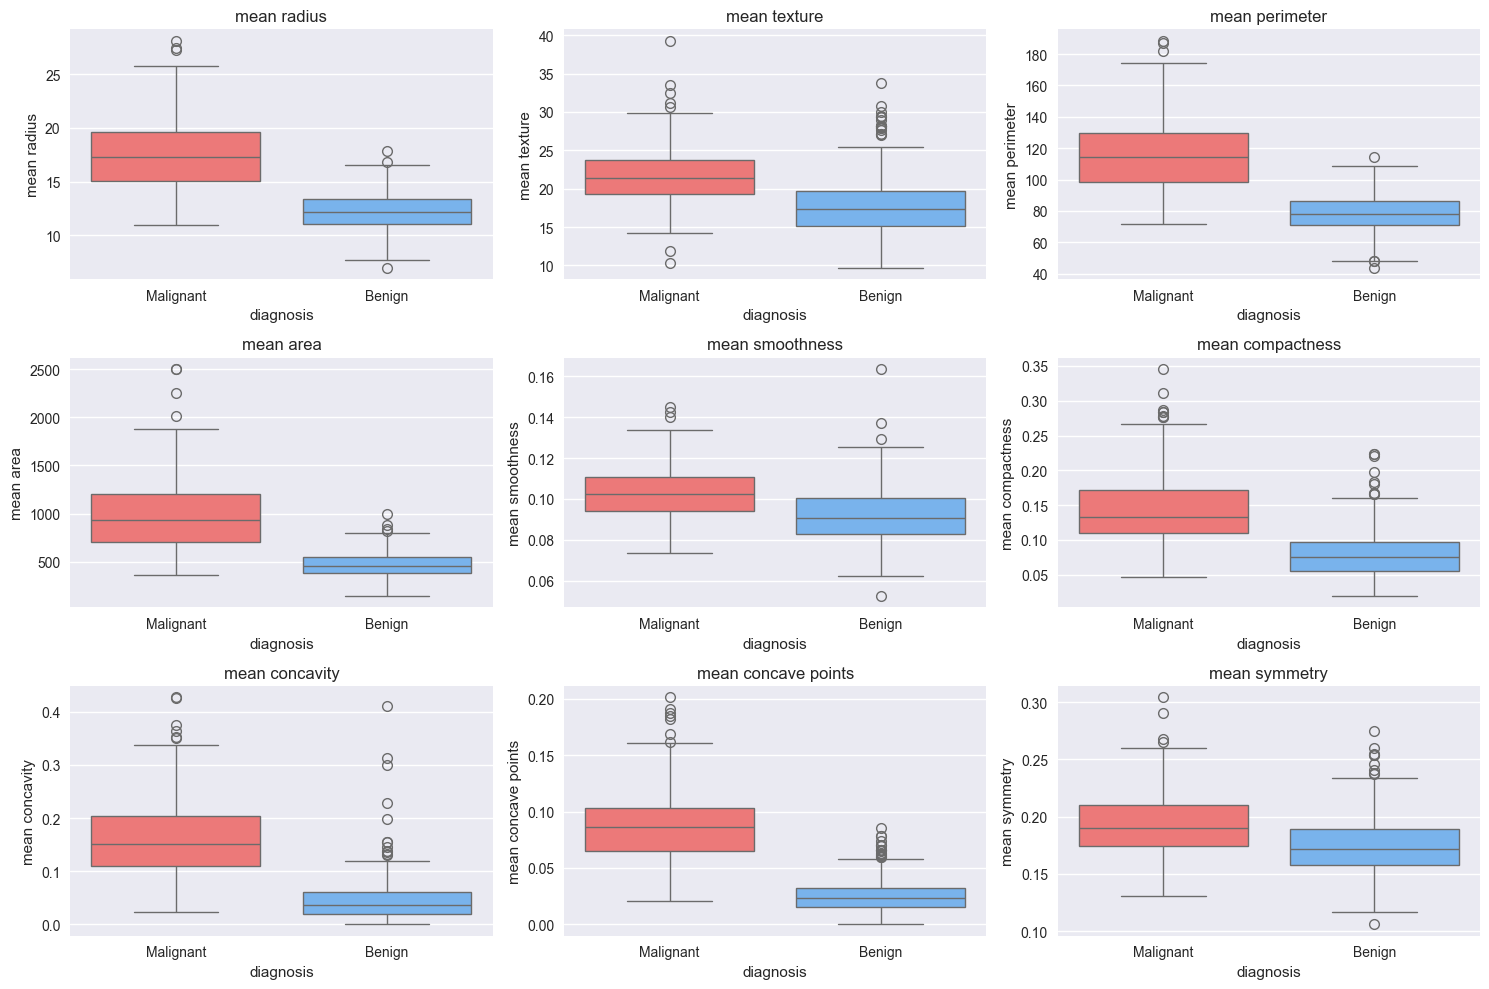

In [14]:
# Important features to visualize
important_features = ['mean radius', 'mean texture', 'mean perimeter', 
                     'mean area', 'mean smoothness', 'mean compactness', 
                     'mean concavity', 'mean concave points', 'mean symmetry']

# Boxplots - Best for seeing differences
plt.figure(figsize=(15, 10))
for i, feature in enumerate(important_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='diagnosis', y=feature, data=df, palette=['#ff6666', '#66b3ff'])
    plt.title(feature)

plt.tight_layout()
plt.show()

In [15]:
# Feature Selection - Part 1: Correlation with Target

# First, encode target numerically (Malignant=1, Benign=0)
df['target'] = df['diagnosis'].map({'Malignant': 1, 'Benign': 0})

# Calculate correlation of all features with target
correlation = df.corr()['target'].sort_values(ascending=False)

print("=== Top 10 Features Most Correlated with Cancer (Malignant) ===")
print(correlation.head(15).round(4))

ValueError: could not convert string to float: 'Malignant'

In [16]:
# Create a clean numeric version for correlation
df_numeric = df.drop(['diagnosis', 'target'], axis=1)  # Remove non-numeric columns

# Now calculate correlation with target
correlation = df_numeric.corrwith(df['target']).sort_values(ascending=False)

print("=== Top 15 Features Most Correlated with Malignant ===")
print(correlation.head(15).round(4))

print("\n=== Bottom 5 Features (Least Correlated) ===")
print(correlation.tail(5).round(4))

=== Top 15 Features Most Correlated with Malignant ===
worst concave points    0.7936
worst perimeter         0.7829
mean concave points     0.7766
worst radius            0.7765
mean perimeter          0.7426
worst area              0.7338
mean radius             0.7300
mean area               0.7090
mean concavity          0.6964
worst concavity         0.6596
mean compactness        0.5965
worst compactness       0.5910
radius error            0.5671
perimeter error         0.5561
area error              0.5482
dtype: float64

=== Bottom 5 Features (Least Correlated) ===
fractal dimension error    0.0780
symmetry error            -0.0065
texture error             -0.0083
mean fractal dimension    -0.0128
smoothness error          -0.0670
dtype: float64


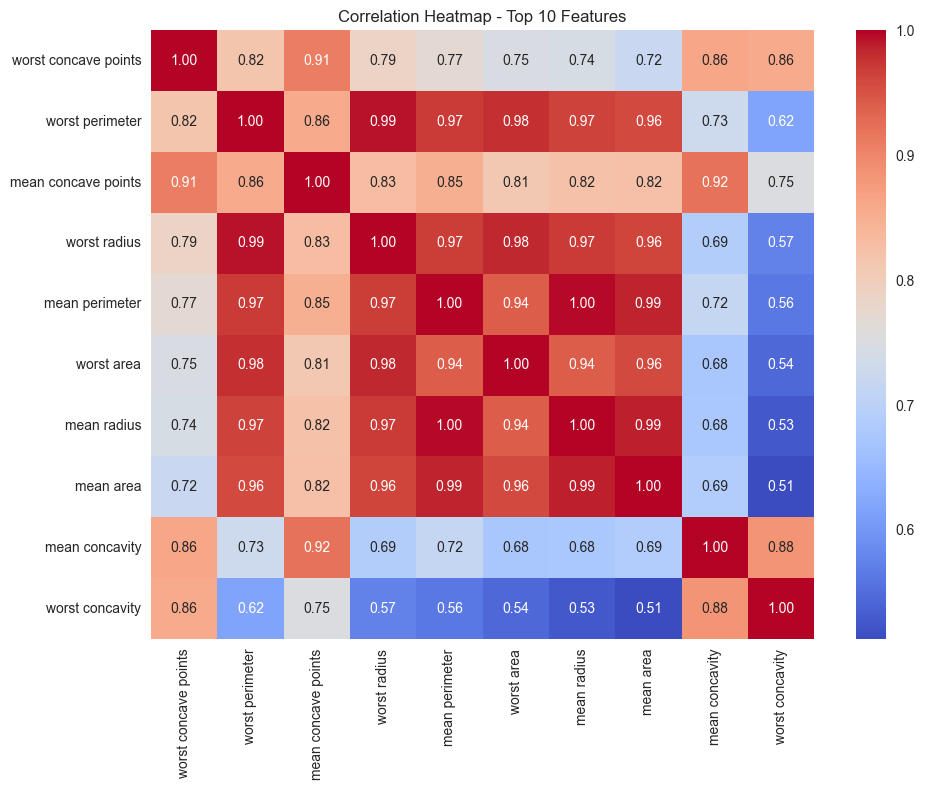

In [17]:
# Top 10 most important features
top_10 = correlation.head(10).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_10].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Top 10 Features')
plt.tight_layout()
plt.show()

In [18]:
# Select Top 12 features
top_features = correlation.head(12).index.tolist()

print("Selected Top 12 Features:")
for i, feature in enumerate(top_features, 1):
    print(f"{i}. {feature}")

# Create final dataframe with selected features
X = df[top_features]           # Features
y = df['target']               # Target (0 = Benign, 1 = Malignant)

print(f"\nFinal dataset shape: {X.shape}")

Selected Top 12 Features:
1. worst concave points
2. worst perimeter
3. mean concave points
4. worst radius
5. mean perimeter
6. worst area
7. mean radius
8. mean area
9. mean concavity
10. worst concavity
11. mean compactness
12. worst compactness

Final dataset shape: (569, 12)


In [19]:
from sklearn.model_selection import train_test_split

# Features and Target
X = df[top_features]      # Top 12 features we selected
y = df['target']          # 0 = Benign, 1 = Malignant

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y           # This helps maintain class distribution
)

print("=== Data Split Completed ===")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Features used:    {X_train.shape[1]}")

=== Data Split Completed ===
Training samples: 455
Testing samples:  114
Features used:    12


In [20]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier viewing (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=top_features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=top_features)

print("Feature scaling completed using StandardScaler.")
print("All features now have mean ≈ 0 and standard deviation ≈ 1")

Feature scaling completed using StandardScaler.
All features now have mean ≈ 0 and standard deviation ≈ 1


In [21]:
print("=== Class Distribution in Training Set ===")
print(y_train.value_counts(normalize=True) * 100)

print("\n=== Class Distribution in Test Set ===")
print(y_test.value_counts(normalize=True) * 100)

=== Class Distribution in Training Set ===
target
0    62.637363
1    37.362637
Name: proportion, dtype: float64

=== Class Distribution in Test Set ===
target
0    63.157895
1    36.842105
Name: proportion, dtype: float64


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

In [24]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

# Dictionary to store results
results = {}

print("Training models...\n")

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': auc
    }
    
    print(f"{name} completed.")

Training models...

Logistic Regression completed.
Random Forest completed.
SVM completed.
XGBoost completed.


In [25]:
# Display results in a nice table
results_df = pd.DataFrame(results).T.round(4)
print("\n=== Model Performance Comparison ===")
print(results_df.sort_values(by='Recall', ascending=False))


=== Model Performance Comparison ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.9737        1.0  0.9286    0.9630   0.9993
XGBoost                0.9649        1.0  0.9048    0.9500   0.9977
Random Forest          0.9561        1.0  0.8810    0.9367   0.9909
SVM                    0.9561        1.0  0.8810    0.9367   0.9987


In [26]:
# Print detailed report for the best model (highest Recall)
best_model_name = results_df['Recall'].idxmax()
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test_scaled)

print(f"\n=== Detailed Classification Report - {best_model_name} ===")
print(classification_report(y_test, y_pred_best, target_names=['Benign', 'Malignant']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))


=== Detailed Classification Report - Logistic Regression ===
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
[[72  0]
 [ 3 39]]


=== Feature Importance (Logistic Regression) ===
                 Feature  Coefficient
5             worst area       1.7542
3           worst radius       1.7192
2    mean concave points       1.4682
1        worst perimeter       1.2170
0   worst concave points       1.2158
9        worst concavity       0.3491
11     worst compactness       0.3036
8         mean concavity       0.2161
7              mean area      -0.0421
4         mean perimeter      -0.3965
6            mean radius      -0.4028
10      mean compactness      -0.7954


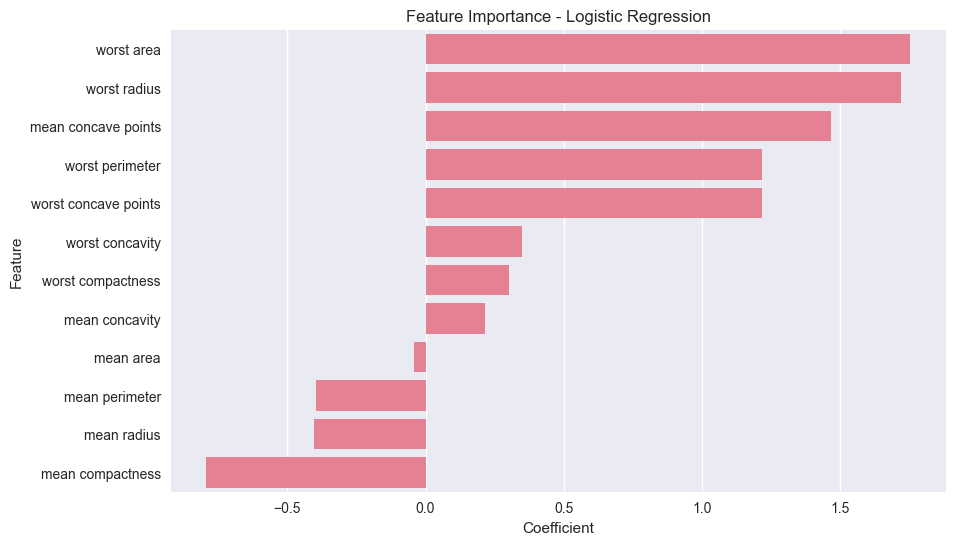

In [27]:
# Feature Importance using Logistic Regression coefficients
coefficients = pd.DataFrame({
    'Feature': top_features,
    'Coefficient': best_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("=== Feature Importance (Logistic Regression) ===")
print(coefficients.round(4))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title('Feature Importance - Logistic Regression')
plt.show()

In [28]:
import joblib

# Save model and scaler
joblib.dump(best_model, '../src/breast_cancer_model.pkl')
joblib.dump(scaler, '../src/scaler.pkl')
joblib.dump(top_features, '../src/top_features.pkl')

print("Model and scaler saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '../src/breast_cancer_model.pkl'

In [30]:
import joblib
import os

# Get the correct path
project_root = os.path.dirname(os.getcwd())  # Goes up from notebooks/ to root
src_path = os.path.join(project_root, 'src')

# Create folder just in case
os.makedirs(src_path, exist_ok=True)

# Save the files
joblib.dump(best_model, os.path.join(src_path, 'breast_cancer_model.pkl'))
joblib.dump(scaler, os.path.join(src_path, 'scaler.pkl'))
joblib.dump(top_features, os.path.join(src_path, 'top_features.pkl'))

print("✅ Files saved successfully in src/ folder!")
print(f"Path used: {src_path}")

✅ Files saved successfully in src/ folder!
Path used: c:\Users\johnpaul\Desktop\Breast-cancer-prediction\src


In [31]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

# Create model with class weights (to improve Recall on Malignant)
best_model_weighted = LogisticRegression(
    random_state=42, 
    max_iter=1000,
    class_weight='balanced'   # This automatically handles imbalance
)

# Stratified K-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross validation scores
cv_accuracy = cross_val_score(best_model_weighted, X_train_scaled, y_train, cv=cv, scoring='accuracy')
cv_recall = cross_val_score(best_model_weighted, X_train_scaled, y_train, cv=cv, scoring='recall')
cv_precision = cross_val_score(best_model_weighted, X_train_scaled, y_train, cv=cv, scoring='precision')
cv_f1 = cross_val_score(best_model_weighted, X_train_scaled, y_train, cv=cv, scoring='f1')
cv_roc_auc = cross_val_score(best_model_weighted, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print("=== 5-Fold Cross Validation Results (with Class Weights) ===")
print(f"Accuracy    : {cv_accuracy.mean():.4f} (± {cv_accuracy.std():.4f})")
print(f"Recall      : {cv_recall.mean():.4f} (± {cv_recall.std():.4f})")
print(f"Precision   : {cv_precision.mean():.4f} (± {cv_precision.std():.4f})")
print(f"F1-Score    : {cv_f1.mean():.4f} (± {cv_f1.std():.4f})")
print(f"ROC-AUC     : {cv_roc_auc.mean():.4f} (± {cv_roc_auc.std():.4f})")

=== 5-Fold Cross Validation Results (with Class Weights) ===
Accuracy    : 0.9385 (± 0.0226)
Recall      : 0.9353 (± 0.0343)
Precision   : 0.9035 (± 0.0286)
F1-Score    : 0.9190 (± 0.0300)
ROC-AUC     : 0.9854 (± 0.0108)


In [32]:
# Train final model with class weights
final_model = LogisticRegression(
    random_state=42, 
    max_iter=1000,
    class_weight='balanced'
)

final_model.fit(X_train_scaled, y_train)

# Evaluate on Test Set
y_pred_final = final_model.predict(X_test_scaled)
y_pred_proba_final = final_model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Final Model Performance on Test Set ===")
print(classification_report(y_test, y_pred_final, target_names=['Benign', 'Malignant']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))


=== Final Model Performance on Test Set ===
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99        72
   Malignant       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix:
[[71  1]
 [ 1 41]]


In [33]:
import joblib
import os

# Create src folder
os.makedirs('src', exist_ok=True)

# === 1. Save Original Model (without class weights) ===
joblib.dump(best_model, 'src/breast_cancer_model_original.pkl')

# === 2. Save Improved Model (with class weights) ===
joblib.dump(final_model, 'src/breast_cancer_model_final.pkl')

# === 3. Save Scaler and Features (common for both) ===
joblib.dump(scaler, 'src/scaler.pkl')
joblib.dump(top_features, 'src/top_features.pkl')

print("✅ Both Models Saved Successfully!")
print("\nFiles saved in 'src/' folder:")
print("1. breast_cancer_model_original.pkl   ← Original Logistic Regression")
print("2. breast_cancer_model_final.pkl     ← With Class Weights (Better Recall)")
print("3. scaler.pkl")
print("4. top_features.pkl")

✅ Both Models Saved Successfully!

Files saved in 'src/' folder:
1. breast_cancer_model_original.pkl   ← Original Logistic Regression
2. breast_cancer_model_final.pkl     ← With Class Weights (Better Recall)
3. scaler.pkl
4. top_features.pkl


In [34]:
import os
print("Current working directory:", os.getcwd())
print("\nFiles in src folder:")
print(os.listdir('src') if os.path.exists('src') else "src folder not found!")

Current working directory: c:\Users\johnpaul\Desktop\Breast-cancer-prediction\notebook

Files in src folder:
['breast_cancer_model_final.pkl', 'breast_cancer_model_original.pkl', 'scaler.pkl', 'top_features.pkl']
